In [ ]:
from src.models import get_llm

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

## Problem Statement (Parralel)
### Input Data
- Name
- Age
- Marks [list[float]]

### Output Data
- Name
- Highest Subject Marks
- Lowest Subject Marks
- Mean Marks
- Median Marks

In [ ]:
from typing import Annotated, List


class ReportCardState(TypedDict):
    name: str
    age: int
    marks: Annotated[
        List[float], "List Containing Each Student Marks in Various Subject"
    ]
    highest_marks: float
    lowest_marks: float
    mean_marks: float
    median_marks: float
    summary: str

In [ ]:
def CalcMeanMarks(state: ReportCardState):
    total_subject = len(state["marks"])
    total_marks = sum(state["marks"])
    mean_marks = total_marks / total_subject
    return {"mean_marks": mean_marks}

In [ ]:
def CalcMedianMarks(state: ReportCardState):
    total_subject = len(state["marks"])
    sorted_marks_list = sorted(state["marks"])
    if total_subject % 2 == 0:
        middle_element_1 = total_subject // 2
        middle_element_2 = (total_subject // 2) + 1
        median_marks_even = (
            sorted_marks_list[middle_element_1] + sorted_marks_list[middle_element_2]
        ) / 2
        return {"median_marks": median_marks_even}
    else:
        middle_element = (total_subject + 1) // 2
        median_marks_odd = sorted_marks_list[middle_element] // 2
        return {"median_marks": median_marks_odd}

In [ ]:
def CalcHighestMarks(state: ReportCardState):
    max_marks = max(state["marks"])
    return {"highest_marks": max_marks}

In [ ]:
def CalcLowestMarks(state: ReportCardState):
    min_marks = min(state["marks"])
    return {"lowest_marks": min_marks}

In [ ]:
def GetSummary(state: ReportCardState):
    summary_text = f"Hi, {state['name']}. You have got Highest Marks as:{state['highest_marks']}, Lowest marks as:{state['lowest_marks']} With Average Marks Being:{state['mean_marks']} and Median Marks Being:{state['median_marks']}"
    state["summary"] = summary_text
    return state

In [ ]:
graph = StateGraph(state_schema=ReportCardState)

In [ ]:
graph.add_node("Mean", CalcMeanMarks)
graph.add_node("Median", CalcMedianMarks)
graph.add_node("Highest", CalcHighestMarks)
graph.add_node("Lowest", CalcLowestMarks)
graph.add_node("Summary", GetSummary)

In [ ]:
graph.add_edge(START, "Mean")
graph.add_edge(START, "Median")
graph.add_edge(START, "Highest")
graph.add_edge(START, "Lowest")

# Aggreagtor
graph.add_edge("Mean", "Summary")
graph.add_edge("Highest", "Summary")
graph.add_edge("Lowest", "Summary")
graph.add_edge("Median", "Summary")
# End
graph.add_edge("Summary", END)

In [ ]:
workflow = graph.compile()

In [ ]:
workflow

In [ ]:
intial_state = {"name": "Gourav", "age": 26, "marks": [12.3, 34.2, 44.3, 56.7, 76.2]}

In [ ]:
final_state = workflow.invoke(intial_state)

In [ ]:
final_state

## LLM Based Parralel Workflow

In [1]:
from langchain_core.prompts import ChatPromptTemplate

In [2]:
eval_prompt_1 = """
You are an expert UPSC Essay Examiner.

Evaluate the candidate's essay objectively.

Assessment Criteria:
- Topic relevance
- Depth of analysis
- Logical organization
- Language quality
- Grammar
- Vocabulary
- Clarity
- Brevity
- Appropriate length
- Overall effectiveness

Assign an overall score between 0.0 and 1.0.



Do not include markdown, explanations, or additional text outside the JSON.
"""

In [3]:
eval_prompt_2 = """
You are an experienced UPSC Essay Examiner.

Evaluate the candidate's essay based only on the following criteria:

1. Clarity of Thought
   - Ideas are clear and easy to understand.
   - Arguments are logically connected.
   - Smooth flow between paragraphs.
   - No ambiguity or unnecessary repetition.

2. Depth of Analysis
   - Demonstrates critical thinking.
   - Explores multiple dimensions of the topic.
   - Supports arguments with reasoning, examples, or evidence.
   - Goes beyond superficial observations.

Assign:
- A clarity score between 0.0 and 1.0.
- A depth of analysis score between 0.0 and 1.0.
- An overall score between 0.0 and 1.0.
"""

In [4]:
eval_prompt_3 = """
You are an experienced UPSC Essay Examiner.

Your task is to critically review the candidate's essay by identifying its limitations, weaknesses, and mistakes.

Evaluate the essay on the following aspects:

1. Content
   - Missing important points
   - Irrelevant information
   - Weak arguments
   - Lack of supporting evidence

2. Logical Reasoning
   - Logical inconsistencies
   - Unsupported claims
   - Contradictory arguments
   - Weak transitions between ideas

3. Language & Grammar
   - Grammatical errors
   - Spelling mistakes
   - Awkward sentence construction
   - Poor vocabulary usage

4. Structure
   - Weak introduction or conclusion
   - Poor paragraph organization
   - Lack of coherence

5. UPSC Essay Standards
   - Insufficient multidimensional analysis
   - Lack of balanced viewpoints
   - Missing critical insights
   - Failure to address the essay topic comprehensively

Assign an overall quality score between 0.0 and 1.0, where:
- 0.0–0.2 : Very Poor
- 0.2–0.4 : Poor
- 0.4–0.6 : Average
- 0.6–0.8 : Good
- 0.8–1.0 : Excellent
"""

In [5]:
from langchain_core.output_parsers import StrOutputParser

In [6]:
parser = StrOutputParser()

In [7]:
eval_chat_prompt = ChatPromptTemplate.from_messages(
    [("system", eval_prompt_1), ("human", "{essay}")]
)

In [8]:
cot_chat_propt = ChatPromptTemplate.from_messages(
    [("system", eval_prompt_2), ("human", "{essay}")]
)

In [9]:
limitation_chat_prompt = ChatPromptTemplate.from_messages(
    [("system", eval_prompt_3), ("human", "{essay}")]
)

In [10]:
summary_prompt = """
You are the Chief UPSC Essay Examiner.

You have received evaluation reports from multiple expert examiners. Each report contains an assessment of a specific aspect of the essay along with its corresponding score.

Your task is to synthesize these evaluations into a single, comprehensive assessment.

The evaluation reports include:
- Clarity of Thought Evaluation
- Depth of Analysis Evaluation
- Limitations and Mistakes Evaluation
- Overall Essay Evaluation

Instructions:
1. Carefully analyze every evaluation report.
2. Identify recurring strengths and weaknesses.
3. Resolve any conflicting opinions using your best judgment.
4. Generate a fair and balanced overall assessment.
5. Compute a final overall score between 0.0 and 1.0 based on all evaluation reports. The score should reflect the candidate's overall essay quality rather than a simple average.
6. Provide constructive feedback that highlights both strengths and areas for improvement.

Do not include any markdown or additional text outside the JSON.
"""

In [11]:
summary_chat_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", summary_prompt),
        ("human", "{cot_outline},{limitation_outline},{cumulative_outline}"),
    ]
)

In [12]:
verdict_prompt = """
You are the Chief UPSC Essay Examiner.

You have received the following evaluation reports:
- Clarity of Thought Evaluation
- Depth of Analysis Evaluation
- Limitations and Mistakes Evaluation
- Overall Evaluation Summary

Your task is to generate a concise and professional final verdict for the candidate.

Instructions:
1. Consider all evaluation reports before forming your verdict.
2. Summarize the candidate's overall performance in a few paragraphs.
3. Highlight the candidate's most significant strengths.
4. Highlight the most important areas requiring improvement.
5. Provide clear and constructive feedback that the candidate can use to improve future essays.
6. Ensure the verdict is balanced, objective, and encouraging without exaggeration.
7. Do not recalculate or modify the final score; use the score provided in the summary evaluation.
"""

In [13]:
verdict_chat_prompt = ChatPromptTemplate.from_messages(
    [("system", verdict_prompt), ("human", "{summary},{cot},{limitaions},{cumulative}")]
)

In [14]:
from src.models import get_llm

llm = get_llm()
# all_models = {f"Model_{x+1}": get_llm() for x in range(5)}

In [15]:
cot_chain = cot_chat_propt | llm | parser
limitation_chain = limitation_chat_prompt | llm | parser
cumulative_chain = eval_chat_prompt | llm | parser
summary_chain = summary_chat_prompt | llm | parser
verdict_chain = verdict_chat_prompt | llm | parser

### Defining Nodes

In [16]:
from typing import TypedDict


class EssayState(TypedDict):
    essay_text: str
    clarity_of_thought_outline: str
    cumulative_analysis_outline: str
    limitation_outline: str
    summary: str
    suggestions: str = None
    verdict: str

In [17]:
def GenerateCotAnalysis(state: EssayState):
    cot_analysis = cot_chain.invoke({"essay": state["essay_text"]})
    return {"clarity_of_thought_outline": cot_analysis}


def GenerateCumulativeAnalysis(state: EssayState):
    cum_analysis = cumulative_chain.invoke({"essay": state["essay_text"]})
    return {"cumulative_analysis_outline": cum_analysis}


def GenerateLimitationAnalysis(state: EssayState):
    limitation_analysis = limitation_chain.invoke({"essay": state["essay_text"]})
    return {"limitation_outline": limitation_analysis}


def GenerateSummaryAnalysis(state: EssayState):
    input_dict = {
        "cot_outline": state["clarity_of_thought_outline"],
        "cumulative_outline": state["cumulative_analysis_outline"],
        "limitation_outline": state["limitation_outline"],
    }
    summary_analysis = summary_chain.invoke(input_dict)
    return {"summary": summary_analysis}


def GenerateVerdictAnalysis(state: EssayState):
    input_dict = {
        "cot": state["clarity_of_thought_outline"],
        "cumulative": state["cumulative_analysis_outline"],
        "limitaions": state["limitation_outline"],
        "summary": state["summary"],
    }
    verdict_analysis = verdict_chain.invoke(input_dict)
    return {"verdict": verdict_analysis}

In [18]:
from langgraph.graph import StateGraph, START, END

EssayGraph = StateGraph(state_schema=EssayState)

### Adding Node

In [19]:
EssayGraph.add_node("cot", GenerateCotAnalysis)
EssayGraph.add_node("summ", GenerateSummaryAnalysis)
EssayGraph.add_node("limit", GenerateLimitationAnalysis)
EssayGraph.add_node("verdict", GenerateVerdictAnalysis)
EssayGraph.add_node("cumulative", GenerateCumulativeAnalysis)

### Adding Edges

In [20]:
EssayGraph.add_edge(START, "cot")
EssayGraph.add_edge(START, "cumulative")
EssayGraph.add_edge(START, "limit")
EssayGraph.add_edge("limit", "summ")
EssayGraph.add_edge("cot", "summ")
EssayGraph.add_edge("cumulative", "summ")
EssayGraph.add_edge("summ", "verdict")
EssayGraph.add_edge("verdict", END)

In [21]:
AgentWorkflow = EssayGraph.compile()

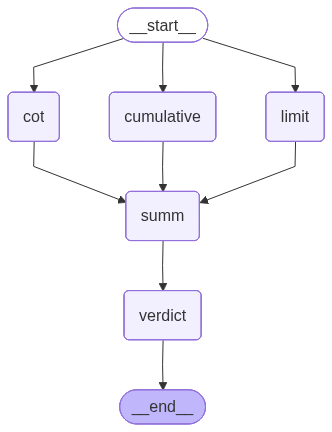

In [22]:
AgentWorkflow

In [23]:
model_essay = """
It is Best to See Life as a Journey, not as a Destination

    27 Jan 2026 19 min read 

“The Bhagavad Gita teaches us that we have the right only to action, not to its fruits – a reminder that life’s true meaning lies not in the destination we reach, but in the journey we undertake.” 

Human life has always been a mystery that thinkers, poets, and philosophers have tried to unravel through the ages. From the earliest civilizations to the modern world, the question of what constitutes a meaningful life has preoccupied the human mind. One of the most profound insights emerging from this reflection is the realization that life is best seen as a journey, not as a destination. To perceive life as a journey is to value growth over arrival, process over outcome, and experience over mere achievement. It is to live fully in the present moment, to embrace both joy and suffering as parts of an evolving process, and to recognize that the essence of life lies not in where we end up, but in how we travel through its varied paths. 

Across cultures and philosophies, this metaphor of life as a journey finds deep resonance. In the Indian spiritual tradition, life is often described as a yatra – a sacred pilgrimage. The Upanishads advocate the idea of “Neti Neti” – “not this, not this” – which signifies the endless quest for truth, where each realization leads to a deeper inquiry. The Buddha spoke of the “Middle Path,” not as a final point of arrival but as a continuous process of awareness and right action. In the Bhagavad Gita, Lord Krishna tells Arjuna that one has the right to perform their actions, but not to the fruits thereof. This timeless teaching captures the essence of journey-oriented living: action, sincerity, and detachment from rigid expectations. Modern thinkers have echoed this wisdom. Ralph Waldo Emerson wrote, “Life is a journey, not a destination,” while Arthur Ashe wrote that “Success is a journey, not a destination.” These reflections, both ancient and modern, underline that true fulfillment comes not from reaching an endpoint, but from constant evolution, learning, and inner growth.  
"""

In [24]:
initial_state = {"essay_text": model_essay}

In [35]:
# from rich import print

# for update in AgentWorkflow.stream(initial_state, stream_mode="updates"):
#     print(update)

In [27]:
final_state = AgentWorkflow.invoke(initial_state)

In [29]:
final_state.keys()

dict_keys(['essay_text', 'clarity_of_thought_outline', 'cumulative_analysis_outline', 'limitation_outline', 'summary', 'verdict'])

In [33]:
from rich import print

print(final_state["cumulative_analysis_outline"])

**Assessment Criteria:**

1. **Topic Relevance:** 0.8
The essay is highly relevant to the topic, as it explores the idea of life as a journey, not a destination, drawing
from various philosophical and cultural perspectives.

2. **Depth of Analysis:** 0.7
The essay provides a good analysis of the concept, but it could delve deeper into the implications and applications
of this idea in everyday life.

3. **Logical Organization:** 0.9
The essay is well-organized, with a clear introduction, body, and conclusion. The author effectively uses 
transitions to connect ideas.

4. **Language Quality:** 0.8
The language is clear, concise, and engaging. The author uses vivid metaphors and quotes to enhance the essay's 
impact.

5. **Grammar:** 0.9
The essay is grammatically correct, with no major errors.

6. **Vocabulary:** 0.8
The author uses a good range of vocabulary, but some words, such as "sacred pilgrimage" and "Neti Neti," might be 
unfamiliar to non-specialists.

7. **Clarity:** 0.9
The essay is easy to follow, and the author's ideas are well-expressed.

8. **Brevity:** 0.6
The essay is a bit too long, considering the word limit. Some sections could be condensed or omitted to make the 
essay more concise.

9. **Appropriate Length:** 0.7
The essay is a bit too long, but it still stays within the acceptable range.

10. **Overall Effectiveness:** 0.8
The essay effectively conveys the idea that life is a journey, not a destination, and provides a good overview of 
various philosophical perspectives on this topic.

**Overall Score:** 0.82